# Imports

In [1]:
import os
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from skimage import measure
from pathlib import Path

import scienceplots
plt.style.use(['science', 'grid'])

from TherMIFASOL.core.variables.GlobalVariables import (
    T_SOLIDUS, T_LIQUIDUS, FAC, COLUMNS_CRED, LINES_CRED
)
from TherMIFASOL.core.variables.BoardCardFilterVariable import (
    boundaries_data_selection, params_first_order, time_constant_parameters, \
    params_clip
)
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer, show_acquisition_time, show_acquisition_start
)
from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array, dl_to_thermo
)
from TherMIFASOL.core.models.EmissivityEmpiricalLaws import (
    first_order_emissivity
)
from TherMIFASOL.core.utils.visualization import (
    setup_contour_parameters
)

In [2]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


data_path_CRED = os.path.join(
    PATH_DATA, "experiences/4 BoardCardFilter/DEC1/CRED/data"
)
data_path_pyrometer = os.path.join(
    PATH_DATA, "experiences/4 BoardCardFilter/DEC1/pyrometer/"
)

array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp500__diaphMIN_bois2.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT100_deg1_diaphMIN_bois2_TRUSTWORTHY.npy"
        )
    )

saving_path = os.path.join(BASE_DIR, "results/BoardFilter/FirstOrder")

# First order phenomenological law


## Pyrometer section

In [3]:
list_beads:list = [11, 12, 13, 14, 15, 16]
FULL_INFO = {id_:{} for id_ in list_beads}
LOCAL_INFO = {id_:{} for id_ in list_beads}

In [4]:
for id_bead in list_beads:
    path_data_bead:str = os.path.join(data_path_pyrometer, f"WLAM_H322_14150_{id_bead}.csv")
    dict_data_bead:dict = collect_data_pyrometer(csv_path=path_data_bead)

    FULL_INFO[id_bead] = dict_data_bead

    low_boundary, _ = boundaries_data_selection[id_bead]
    mask = dict_data_bead['array time'] > low_boundary

    LOCAL_INFO[id_bead]['array time'] = dict_data_bead['array time'][mask] - low_boundary
    LOCAL_INFO[id_bead]['array MAtemp2C'] = dict_data_bead['array MAtemp2C'][mask]
    LOCAL_INFO[id_bead]['array MAemissivity'] = dict_data_bead['array MAemissivity'][mask]


### First order law to fit

Black box that should take into consideration coupled phenomena (oxidation rate, argon flow, thermal gradients and state change)
- $\varepsilon(t, d) = \varepsilon_{non-oxy} + (\varepsilon_{oxy} - \varepsilon_{non-oxy})\left(1 - \exp\left(\displaystyle\frac{-(t-t_0)}{\tau(d)}\right)\right)$ avec $\varepsilon_{non-oxy} = 0.23$ et $\varepsilon_{oxy} = 0.73$



In [5]:
fake_time = np.arange(0, 5, 0.001)
def first_order_V0(time, depth, delay, eps_non_oxy=0.23, eps_oxy=0.73):
    tau = depth  # Find the evolution low along the depth.
    res = np.where(time < delay, eps_non_oxy, eps_non_oxy + (eps_oxy - eps_non_oxy) * (1 - np.exp(-(time - delay) / tau)))
    return res

### Optimize first order law

'depth' optimized: 0.08051930926028154


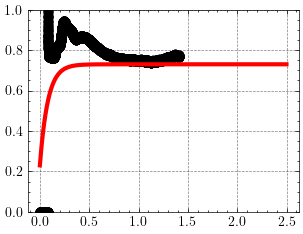

In [6]:
cordon=12
delay=0.38

array_time = LOCAL_INFO[cordon]['array time']
array_emissivity = LOCAL_INFO[cordon]['array MAemissivity']
array_filter = (array_time > delay)


fake_time = np.arange(0, 2.5, 0.001)
def first_order_optimization(time, depth, eps_non_oxy=0.23, eps_oxy=0.73):
    tau = depth  # Find the evolution low along the depth.
    return eps_non_oxy + (eps_oxy - eps_non_oxy) * (1 - np.exp(-(time) / tau))

# Adjust model to data
params, _ = curve_fit(
    f=first_order_optimization, 
    xdata=array_time[array_filter]-delay, 
    ydata=array_emissivity[array_filter],
    p0=0.5
    )
# Extract 'depth' parameter from optimization
depth_fitted = params[0]
print("'depth' optimized:", depth_fitted)

plot=True
if plot:
    plt.scatter(array_time[array_filter]-delay, array_emissivity[array_filter], c='k')
    plt.plot(fake_time, first_order_optimization(fake_time, depth_fitted), c='r', lw=3)
    plt.ylim(0,1)
    plt.grid(True)
    plt.show()

# 11 : 0.05658331345784039   | delay : 0.22
# 12 : 0.08051930919763058   | delay : 0.38
# 13 : 0.12800591741519407   | delay : 0.1
# 14 : 0.21471762408634126   | delay : 0.1
# 15 : 0.48463491693863536   | delay : 0.145
# 16 : 0.60600737529380160   | delay : 0.15

### Visualization of first order fitted law

In [7]:
for id_bead in list_beads:
    show_acquisition_time(FULL_INFO[id_bead])

Acquisition time : 4.569374 sec
Acquisition time : 4.569378 sec
Acquisition time : 4.262417 sec
Acquisition time : 4.5647839999999995 sec
Acquisition time : 4.5649560000000005 sec
Acquisition time : 4.278296 sec


In [9]:
for id_bead in list_beads:
    show_acquisition_start(FULL_INFO[id_bead])

Start time acquisition : 11:52:39,729082
Start time acquisition : 11:53:09,641121
Start time acquisition : 11:53:39,256306
Start time acquisition : 11:54:09,370364
Start time acquisition : 11:54:41,378450
Start time acquisition : 11:55:13,570797


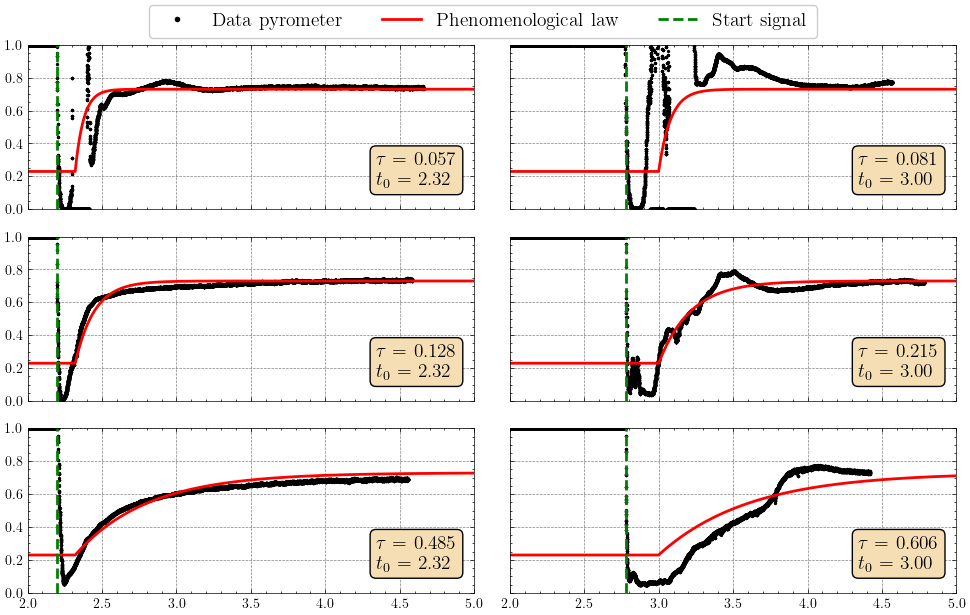

In [8]:
fake_time = np.arange(0, 5, 0.001)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 6), sharex=True, sharey=True)
for idx, id_bead in enumerate(list_beads):
    row, col = divmod(idx, 2)

    # Pyrometer data
    TIME_pyrometer = np.copy(FULL_INFO[id_bead]['array time'])
    EMI_pyrometer = np.copy(FULL_INFO[id_bead]['array MAemissivity'])
    # critical_index = np.where(EMI_pyrometer < 0.8)[0][0]    
    
    # Phenomenological law
    tau = params_first_order[id_bead]['tau']
    delay = params_first_order[id_bead]['delay']

    if id_bead == 11:
        TIME_pyrometer+=0.09
    elif id_bead == 13:
        TIME_pyrometer+=0.32
    elif id_bead ==14:
        TIME_pyrometer+=0.22
    elif id_bead ==15:
        TIME_pyrometer-=0.01
    elif id_bead ==16:
        TIME_pyrometer+=0.14

    # Plot temperature
    axes[row, col].scatter(
        TIME_pyrometer, EMI_pyrometer, 
        label='Pyrometer', s=2, c='k'
        )
    axes[row, col].plot(
        fake_time, first_order_V0(fake_time, tau, delay), 
        c='red', lw=2,)
    axes[row, col].set_ylim(ymin=0, ymax=1)
    axes[row, col].tick_params(axis='both', which='major', labelsize=10)
    
    # Ajouter une annotation pour afficher les paramètres
    annotation_text = r"$\tau$ = " +f"{tau:.3f}\n"+r"$t_0$ = " +f"{delay:.2f}"
    axes[row, col].annotate(
        annotation_text, xy=(0.78, 0.35), xycoords='axes fraction',
        fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='wheat')
        )

    # axes[row, col].legend()
    if id_bead % 2 == 1:  # impairs
        # axes[row, col].set_xlim(xmin=0, xmax=1.9)
        axes[row, col].set_xlim(xmin=2, xmax=5)
        axes[row, col].vlines(x=2.2, ymin=0, ymax=1, color='g', lw=2, ls='--')
    else:
        # axes[row, col].set_xlim(xmin=0, xmax=2.5)
        axes[row, col].set_xlim(xmin=2, xmax=5)
        axes[row, col].vlines(x=2.78, ymin=0, ymax=1, color='g', lw=2, ls='--')


plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.3)

# Créer des objets graphiques temporaires pour la légende
legend_pyro = plt.Line2D([], [], color='k', marker='o', linestyle='None', markersize=3, label='Data pyrometer')
legend_cam = plt.Line2D([], [], color='r', linestyle='-', lw=2, label='Phenomenological law')
legend_ref = plt.Line2D([], [], color='g', linestyle='--', lw=2, label='Start signal')

# Ajouter une légende commune au-dessus des sous-graphiques
fig.legend(handles=[legend_pyro, legend_cam, legend_ref], loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05), fontsize=14)

plt.tight_layout()
# fig.savefig(
#     os.path.join(saving_path, "first_order_phenomenological_law.png"),
#     format='png', bbox_inches='tight', dpi=400, transparent=True
# )
plt.show()


### Evolution law for tau
> :warning:


|cordons impairs: | 11 | 13 | 15 |
|-------------|--|--|-------------|
|tau evolution: |0.06 | 0.19 | 0.60|

|cordons pairs: | 12 | 14 | 16|
|-------------|--|--|-------------|
|tau evolution: |0.10| 0.21| 0.85|

#### Even beads

In [9]:
offset_depth = 1.2

x_even = np.asarray([i+offset_depth for i in np.arange(0, 4.8, 1.6)])
y_even = np.asarray([params_first_order[i]['tau'] for i in list_beads[1::2]])

degree = 2
params_tau_evolve_even = np.polyfit(x_even, y_even, degree)

def tau_evolve_even(depth):
    tau = np.sum([params_tau_evolve_even[i]*depth**(degree-i) for i in range(degree+1)])
    return tau

#### Odds beads

In [10]:
offset_depth = 0.4

x_odd = np.asarray([i+offset_depth for i in np.arange(0, 4.8, 1.6)])
y_odd = np.asarray([params_first_order[i]['tau'] for i in list_beads[::2]])
degree = 2
params_tau_evolve_odd = np.polyfit(x_odd, y_odd, degree)

def tau_evolve_odd(depth):
    tau = np.sum([params_tau_evolve_odd[i]*depth**(degree-i) for i in range(degree+1)])
    return tau

#### Full except bead 14

In [11]:
offset_depth = 0.4

x_full = np.asarray([i+offset_depth for i in np.arange(0, 4.8, 0.8)])
y_full = np.asarray([params_first_order[i]['tau'] for i in list_beads])

def tau_evolve_full(depth, coef1, coef2, coef3):
    tau = coef1 *depth**4 +  coef2* depth**2 + coef3
    return tau

def tau_evolve(depth, coef1, coef2):
    tau = coef1* depth**2 + coef2
    return tau

def tau_evolve_full_3(depth, coef1, coef2, coef3):
    tau = coef1 * np.exp(depth * coef2) + coef3
    return tau


params_tau_evolve_full, _ = curve_fit(tau_evolve_full, x_full, y_full)
params_tau_evolve, _ = curve_fit(tau_evolve, x_full, y_full)
params_tau_evolve_full_3, _ = curve_fit(tau_evolve_full_3, x_full, y_full)


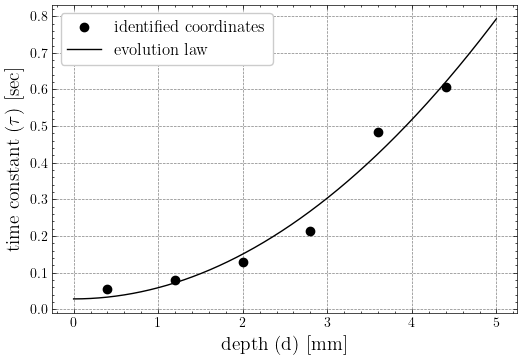

In [13]:
depth_fake = np.arange(0,5,0.001)

tau_even = [tau_evolve_even(i) for i in depth_fake]
tau_odd = [tau_evolve_odd(i) for i in depth_fake]
tau_full = [tau_evolve_full(i, *params_tau_evolve_full) for i in depth_fake]
tau_full_2 = [tau_evolve(i, *params_tau_evolve) for i in depth_fake]
tau_full_3 = [tau_evolve_full_3(i, *params_tau_evolve_full_3) for i in depth_fake]

plt.subplots(figsize=(6, 4))
# plt.scatter(x_even, y_even, c='b', edgecolor='k', label='sample even')
# plt.scatter(x_odd, y_odd, c='g', edgecolor='k', label='sample odd')
plt.scatter(x_full, y_full, c='k', edgecolor='k', label='identified coordinates')

# plt.plot(depth_fake, tau_even, label='even', c='b')
# plt.plot(depth_fake, tau_odd, label='odd', c='g')
# plt.plot(depth_fake, tau_full, label='full', c='r')
plt.plot(depth_fake, tau_full_2, label="evolution law", c='k')
# plt.plot(depth_fake, tau_full_3, label='full 3', c='g')

# plt.title(r'Evolution of parameter $\tau$ according to depth')
plt.xlabel("depth (d) [mm]", fontsize=14)
plt.ylabel("time constant " + r"($\tau$)"+" [sec]", fontsize=14)
plt.legend(ncols=1, fontsize=12)
plt.savefig(
    os.path.join(saving_path, "evolution_law.pdf"),
    format='pdf', bbox_inches='tight', transparent=True
)
plt.show()

# matrix implementation

In [14]:
_, depth_matrix = np.meshgrid(
    np.arange(0, 640, 1),
    np.arange(0, 512, 1),
)

upper_limit=250  # top surface : equivalent to 0 mm

mask_prof = np.zeros_like(depth_matrix, dtype=bool)
mask_prof[:upper_limit,:]=True  # True == unwanted values

In [15]:
y_matrix_pos = (np.arange(0, 512) - upper_limit)*FAC
x_matrix_pos = (np.arange(0, 640))*FAC/16.7

time_contribution, depth_contribution = np.meshgrid(
    x_matrix_pos, y_matrix_pos
)

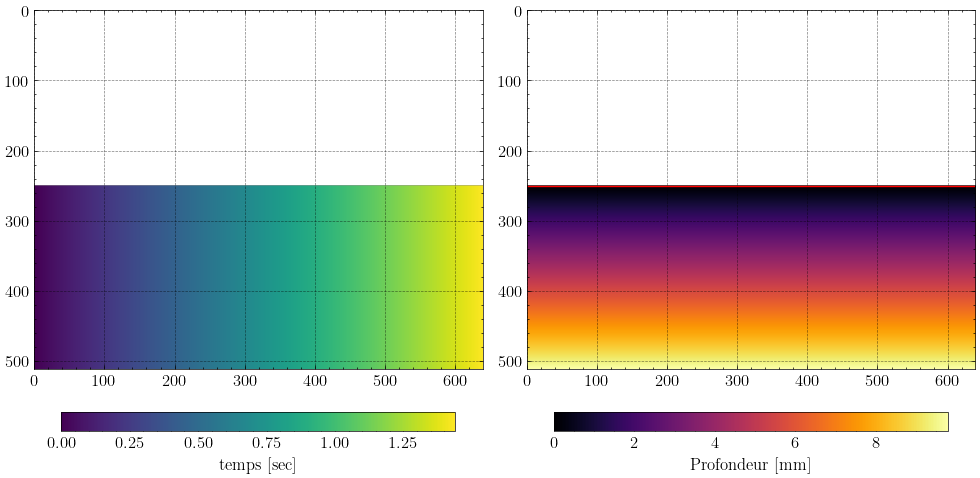

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

im1 = axes[0].imshow(np.ma.masked_array(time_contribution, mask_prof), cmap='viridis', vmin=0, vmax=1.44)
# axes[0].set_title('time contribution')
axes[0].vlines(x=int(delay*16.7/FAC), ymin=0, ymax=512, color='r')
# axes[0].axis('off')  # Désactiver les axes
cbar1 = fig.colorbar(im1, ax=axes[0], orientation='horizontal', fraction=0.046, pad=0.10)
cbar1.set_label('temps [sec]', fontsize=12)
cbar1.ax.tick_params(labelsize=12) 

im2 = axes[1].imshow(np.ma.masked_array(depth_contribution, mask_prof), cmap='inferno')
# axes[1].set_title('depth contribution')
axes[1].hlines(y=upper_limit, xmin=0, xmax=640, color='r')
# axes[1].axis('off')  # Désactiver les axes
cbar2 = fig.colorbar(im2, ax=axes[1], orientation='horizontal', fraction=0.046, pad=0.10)
cbar2.set_label('Profondeur [mm]', fontsize=12)
cbar2.ax.tick_params(labelsize=12) 

for ax in axes.flatten():
    ax.set_xlim(0, 639)
    ax.set_ylim(511, 0)
    ax.tick_params(axis='both', which='major', labelsize=12)

# Afficher la figure
plt.tight_layout()
# plt.savefig("../resultats/time_and_depth_array_contribution.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

# Emissivity field

In [17]:
emissivity_field = first_order_emissivity(
    time=time_contribution,
    depth=depth_contribution,
    delay=0.0,
    eps_non_oxy=0.23,
    eps_oxy=0.73,
    params_tau_evolve=time_constant_parameters
)

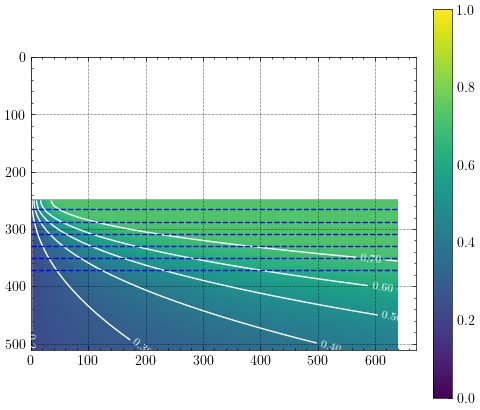

In [18]:
offset_depth = 0.4
custom_levels = np.array([0.23, 0.3, 0.4, 0.5, 0.6, 0.7]) 
x_full = np.asarray([i+offset_depth for i in np.arange(0, 4.8, 0.8)])


fig, axes = plt.subplots(1, 1, figsize=(5, 5))
field = np.ma.masked_array(emissivity_field, mask_prof)
im1 = axes.imshow(field, cmap='viridis', vmin=0, vmax=1)
contour = axes.contour(field, levels=custom_levels, colors='white', linewidths=1) 
axes.hlines(y=x_full/FAC + 255, xmin=0, xmax=640, colors='b', ls='--', lw=1)
axes.clabel(contour, inline=True, fontsize=8, fmt='%.2f') 
# axes[0].axis('off')  # Désactiver les axes
fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

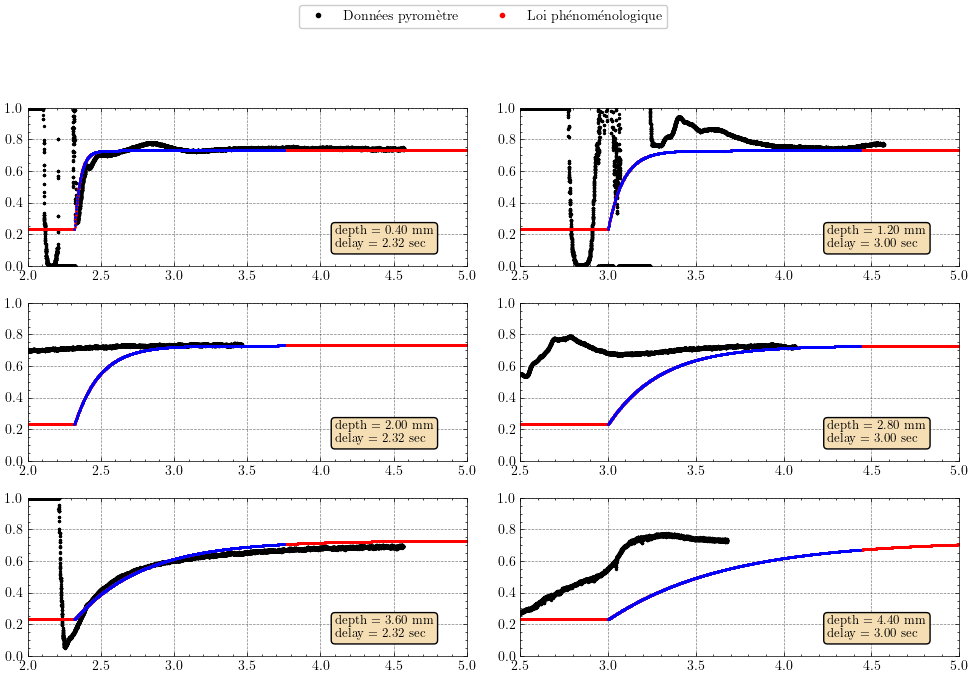

In [19]:
fake_time = np.arange(0, 5, 0.001)
x_pixels = np.asarray(x_full/FAC + 255, dtype=int)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 6))
for idx, (px, cordon) in enumerate(zip(x_pixels, list_beads)):
    row, col = divmod(idx, 2)

    # Pyrometer data
    Raw_data_time_pyrometer = np.copy(FULL_INFO[cordon]['array time'])
    Raw_data_TwoColorTemperature_pyrometer = FULL_INFO[cordon]['array MAemissivity']

    if cordon == 13:
        Raw_data_time_pyrometer-=0.8
    elif cordon ==14:
        Raw_data_time_pyrometer-=0.5
    elif cordon ==16:
        Raw_data_time_pyrometer-=0.6

    # Phenomenological law
    depth = x_full[idx]
    delay = params_first_order[cordon]['delay']

    # Emissivity field profile
    emissivity_field_profile = emissivity_field[px,:]
    time_profile = time_contribution[px,:] + delay

    # Plot emissivity profile
    emissivity_profile = first_order_emissivity(
        time=fake_time, 
        depth=(px - upper_limit)*FAC, # [mm]
        delay=delay,
        params_tau_evolve=time_constant_parameters,
        eps_non_oxy= 0.23,
        eps_oxy= 0.73
        )
    axes[row, col].scatter(Raw_data_time_pyrometer, Raw_data_TwoColorTemperature_pyrometer, label='Pyrometer', s=2, c='k')
    axes[row, col].scatter(fake_time, emissivity_profile, s=1, c='red', label='Camera: Sillage pyrometer')
    axes[row, col].scatter(time_profile, emissivity_field_profile, s=1, c='blue', label='Emissivity field profile')
    axes[row, col].set_ylim(ymin=0, ymax=1)
    
    # Ajouter une annotation pour afficher les paramètres
    # annotation_text = r"$\tau$ = " +f"{tau:.2f}\ndelay = {delay:.2f}"
    annotation_text = r"depth = " +f"{depth:.2f} mm\ndelay = {delay:.2f} sec"
    axes[row, col].annotate(
        annotation_text, xy=(0.70, 0.25), xycoords='axes fraction',
        fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='wheat')
        )

    # axes[row, col].legend()
    if cordon % 2 == 0:
        # axes[row, col].set_xlim(xmin=0, xmax=1.9)
        axes[row, col].set_xlim(xmin=2.5, xmax=5)
    else:
        # axes[row, col].set_xlim(xmin=0, xmax=2.5)
        axes[row, col].set_xlim(xmin=2, xmax=5)

plt.subplots_adjust(right=0.85, hspace=0.4, wspace=0.3)

# Créer des objets graphiques temporaires pour la légende
legend_pyro = plt.Line2D([], [], color='k', marker='o', linestyle='None', markersize=3, label='Données pyromètre')
legend_cam = plt.Line2D([], [], color='r', marker='o', linestyle='None', markersize=3, label='Loi phénoménologique')

# Ajouter une légende commune au-dessus des sous-graphiques
fig.legend(handles=[legend_pyro, legend_cam], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.15))

plt.tight_layout()
plt.show()

# Implementation

## First order law
- Evolution law according to depth and time. Parameter 'tau' characterize the time constant.
- First task is to link 'tau' to the depth from the top surface which the pyrometer profiles are related to.
- Bead 14 has been excluded because of an inconsistent data.
- Delay describe the time which the first order law start, but it's not still well understood

In [20]:
# Emissivity field
upper_limit=255  # top surface : equivalent to 0 mm
delay = 0.1

y_matrix_pos = (np.arange(0, 512) - upper_limit)*FAC
x_matrix_pos = np.arange(0, 640)*FAC/16.7

time_contribution, depth_contribution = np.meshgrid(
    x_matrix_pos,
    y_matrix_pos
)

emissivity_profile = first_order_emissivity(
    time=time_contribution, 
    depth=depth_contribution,
    delay=delay,
    params_tau_evolve=time_constant_parameters,
    eps_non_oxy= 0.23,
    eps_oxy= 0.73
    )

mask_prof = np.zeros_like(emissivity_field, dtype=bool)
mask_prof[:upper_limit,:]=True  # True == unwanted values

## Emissivity - time evolution

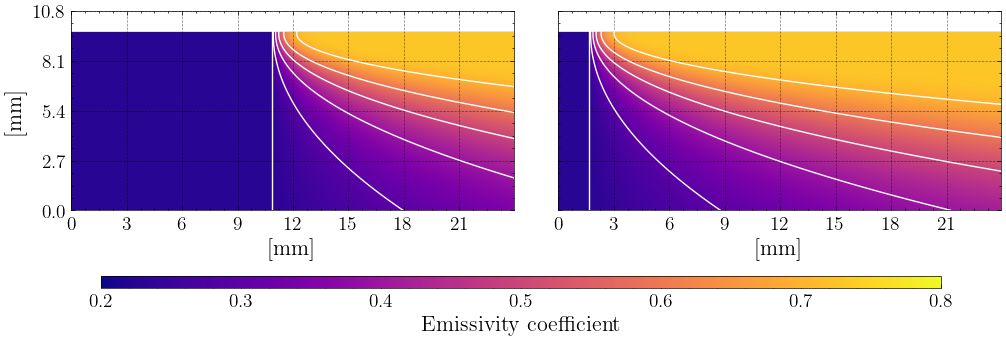

In [25]:
# import matplotlib
# matplotlib.use('TkAgg')  # ou 'Qt5Agg'

# Contour and extent setup.
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)
X, Y = np.meshgrid(x_contour, y_contour)


# Set two different emissivity profile through two different delay.
emissivity_profile_1 = first_order_emissivity(
    time=time_contribution, 
    depth=depth_contribution,
    delay=0.65,
    params_tau_evolve=time_constant_parameters,
    eps_non_oxy= 0.23,
    eps_oxy= 0.73
    )
emissivity_profile_2 = first_order_emissivity(
    time=time_contribution, 
    depth=depth_contribution,
    delay=0.10,
    params_tau_evolve=time_constant_parameters,
    eps_non_oxy= 0.23,
    eps_oxy= 0.73
    )

# Custom levels for contour plotting
custom_levels = np.array([0.23, 0.3, 0.4, 0.5, 0.6, 0.7])


# Création de la figure et des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharex=True, sharey=True)

# Affichage du premier champ thermique
# axes[0].set_title(r"Uniform Emissivity Field $\varepsilon = " + f"{eps0}$")
IMAGE_1 = np.ma.masked_array(emissivity_profile_1, mask=mask_prof)
im1 = axes[0].imshow(IMAGE_1, cmap='plasma', extent=extent, vmin=0.2, vmax=0.8)
axes[0].set_ylabel('[mm]', fontsize=16)
iso_emi = axes[0].contour(X, Y, emissivity_profile_1, levels=custom_levels, colors='white', linewidths=1)
# axes[0].clabel(iso_emi, inline=True, fontsize=10, fmt='%.2f')


# Affichage du deuxième champ thermique
# axes[1].set_title("Phenomenological Emissivity Field")
IMAGE_2 = np.ma.masked_array(emissivity_profile_2, mask=mask_prof)
im2 = axes[1].imshow(IMAGE_2, cmap='plasma', extent=extent, vmin=0.2, vmax=0.8)
iso_emi = axes[1].contour(X, Y, emissivity_profile_2, levels=custom_levels, colors='white', linewidths=1)
# axes[1].clabel(iso_emi, inline=True, fontsize=10, fmt='%.2f')


for ax in axes:
    ax.set_xlabel('[mm]', fontsize=16)
    ax.set_xticks(xtick_pixels * FAC)
    ax.set_yticks(ytick_pixels * FAC)
    ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC], fontsize=14)
    ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC], fontsize=14)
    ax.set_ylim(ymin=0, ymax=10.8)

# Ajout de la colorbar
cbar_ax = fig.add_axes([0.15, 0.2, 0.7, 0.02])
cbar = fig.colorbar(im2, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Emissivity coefficient", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.subplots_adjust(right=0.9, hspace=0.15, wspace=0.1)
plt.savefig(
    os.path.join(saving_path, "emissivity_field_sidebyside.pdf"),
    format='pdf', bbox_inches='tight', transparent=True
)
plt.show()

## Application

In [26]:
c_cordon = 13
img = 320
path_raw_data_layer = os.path.join(data_path_CRED, f"layer_{c_cordon}")

# Raw image
try:
    dl_raw = load_cred_array(os.path.join(path_raw_data_layer, f"im_{img}.npy"))
except Exception as e:
    print(f"Error processing images: {e}")
    raise

# Thermal image from homogenous emissivity field
thermal_image_uniform_emissivity_field = np.flipud(
        dl_to_thermo(
            dl_raw=dl_raw,
            nuc_table=array_nuc,
            calibration_table=array_calibration,
            emissivity=0.73
        )
)


# Emissivity field
emissivity_field = first_order_emissivity(
    time=time_contribution,
    depth=depth_contribution,
    delay=0.1,
    eps_non_oxy=0.23,
    eps_oxy=0.73,
    params_tau_evolve=time_constant_parameters
)

# Thermal image from heterogenous emissivity field
thermal_image_heterogenous_emissivity_field = np.flipud(
        dl_to_thermo(
            dl_raw=dl_raw,
            nuc_table=array_nuc,
            calibration_table=array_calibration,
            emissivity=emissivity_field
        )
)

### Plot emissivity field

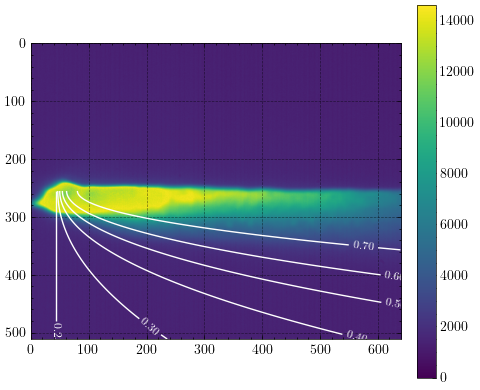

In [27]:
# Custom levels for contour plotting
custom_levels = np.array([0.23, 0.3, 0.4, 0.5, 0.6, 0.7])

# Plotting
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
field = np.ma.masked_array(emissivity_field, mask_prof)

# Display the raw image
im1 = axes.imshow(np.flipud(dl_raw), cmap='viridis')

# Add contour lines
contour = axes.contour(field, levels=custom_levels, colors='white', linewidths=1)
axes.clabel(contour, inline=True, fontsize=8, fmt='%.2f')

# Add color bar
fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.046, pad=0.04)

# Improve layout
plt.tight_layout()
plt.show()

### Homogenous VS heterogenous emissivity field

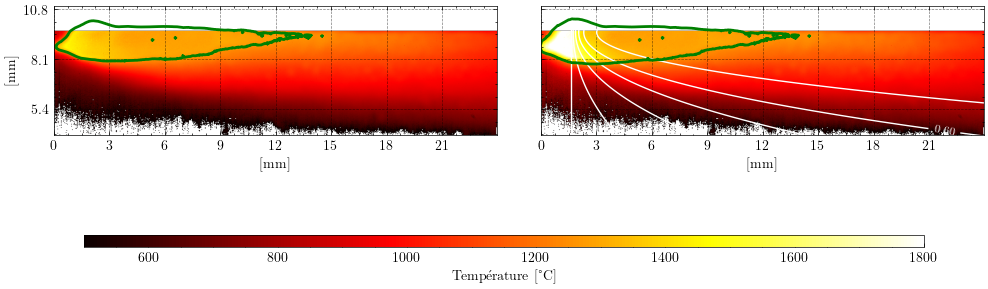

In [29]:
c_cordon = 13
crop_low=params_clip[c_cordon]['crop low']
crop_high=params_clip[c_cordon]['crop high']

# Contour and extent setup.
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)
X, Y = np.meshgrid(x_contour, y_contour)

# Custom levels for contour plotting
custom_levels = np.array([0.23, 0.3, 0.4, 0.5, 0.6, 0.7])

# Création de la figure et des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharex=True, sharey=True)

# Affichage du premier champ thermique
# axes[0].set_title(r"Uniform Emissivity Field $\varepsilon = " + f"{eps0}$")
IMAGE_1 = np.ma.masked_array(thermal_image_uniform_emissivity_field, mask=mask_prof)
im1 = axes[0].imshow(IMAGE_1 - 273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)

# Isotherms
contours_1 = measure.find_contours(
    thermal_image_uniform_emissivity_field, 
    T_SOLIDUS
    )
for contour in contours_1:
    symmetrical_contour = np.array(contour)
    symmetrical_contour[:, 0] = LINES_CRED - contour[:, 0]  # Symétrie sur l'axe Y
    axes[0].plot(symmetrical_contour[:, 1] * FAC, symmetrical_contour[:, 0] * FAC, color='green', linewidth=2)

axes[0].set_ylabel('[mm]')



# Affichage du deuxième champ thermique
# axes[1].set_title("Phenomenological Emissivity Field")
IMAGE_2 = np.ma.masked_array(thermal_image_heterogenous_emissivity_field, mask=mask_prof)
im2 = axes[1].imshow(IMAGE_2 - 273.15, cmap='hot', extent=extent, vmin=500, vmax=1800)

# Superposer les isovaleurs du champ d'émissivité
iso_emi = axes[1].contour(X, Y, emissivity_field, levels=custom_levels, colors='white', linewidths=1)
axes[1].clabel(iso_emi, inline=True, fontsize=8, fmt='%.2f')

# Isotherms
contours_2 = measure.find_contours(
    thermal_image_heterogenous_emissivity_field, 
    T_SOLIDUS
    )
for contour in contours_2:
    symmetrical_contour = np.array(contour)
    symmetrical_contour[:, 0] = LINES_CRED - contour[:, 0]  # Symétrie sur l'axe Y
    axes[1].plot(symmetrical_contour[:, 1] * FAC, symmetrical_contour[:, 0] * FAC, color='green', linewidth=2)


for ax in axes:
    ax.set_xlabel('[mm]')
    ax.set_xticks(xtick_pixels * FAC)
    ax.set_yticks(ytick_pixels * FAC)
    ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC])
    ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC])
    # ax.set_ylim(ymin=crop_low,ymax=crop_high)
    ax.set_ylim(ymin=4,ymax=11)

# Ajout de la colorbar
cbar_ax = fig.add_axes([0.15, 0.2, 0.7, 0.02])
cbar = fig.colorbar(im2, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Température [°C]')

plt.subplots_adjust(right=0.9, hspace=0.15, wspace=0.1)
# plt.savefig("../resultats/comparaison_methods.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

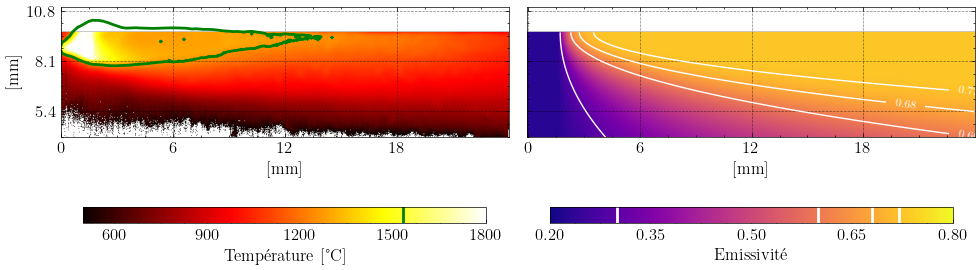

In [ ]:
# Limits and levels
lim_low = 0.2
lim_high = 0.8
custom_levels = [0.3, 0.6, 0.68, 0.72]
T_low = 500
T_high = 1800
ticks_emi = np.linspace(lim_low, lim_high, 5)
ticks_temp = np.linspace(600, T_high, 5)
lim = 218

# Contour and extent setup.
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)
X, Y = np.meshgrid(np.arange(COLUMNS_CRED), np.arange(LINES_CRED))

# Process images
image1 = np.ma.masked_array(thermal_image_heterogenous_emissivity_field, mask=mask_prof)
image2 = np.ma.masked_array(emissivity_field, mask=mask_prof)


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# Plot temperature image with contours
contours_1 = measure.find_contours(image1, T_SOLIDUS)
for contour in contours_1:
    symmetrical_contour = np.array(contour)
    symmetrical_contour[:, 0] = contour[:, 0]  # Symmetry on Y-axis
    axes[0].plot(symmetrical_contour[:, 1], symmetrical_contour[:, 0], color='green', linewidth=2)

im1 = axes[0].imshow(image1 - 273.15, vmin=T_low, vmax=T_high, cmap='hot')
cbar1 = plt.colorbar(im1, ax=axes[0], orientation='horizontal', shrink=0.9, aspect=25, pad=0.15)
cbar1.set_label('Température [°C]', fontsize=12)
cbar1.ax.axvline(T_SOLIDUS-273.15, color='green', linewidth=2)
cbar1.set_ticks(ticks_temp)
cbar1.set_ticklabels([f"{t:.0f}" for t in ticks_temp])
cbar1.ax.tick_params(labelsize=12)

axes[0].set_xlabel('[mm]', fontsize=12)
axes[0].set_ylabel('[mm]', fontsize=12)


# Plot emissivity image with contours
iso_emi = axes[1].contour(X, Y, image2, levels=custom_levels, colors='white', linewidths=1)
axes[1].clabel(iso_emi, inline=True, fontsize=8, fmt='%.2f')

im2 = axes[1].imshow(image2, vmin=lim_low, vmax=lim_high, cmap='plasma')
cbar2 = plt.colorbar(im2, ax=axes[1], orientation='horizontal', shrink=0.9, aspect=25, pad=0.15)
cbar2.set_label('Emissivité', fontsize=12)
cbar2.set_ticks(ticks_emi)
cbar2.set_ticklabels([f"{t:.2f}" for t in ticks_emi])
cbar2.ax.tick_params(labelsize=12)

axes[1].set_xlabel('[mm]', fontsize=12)
for level in custom_levels:
    cbar2.ax.axvline(level, color='white', linewidth=2, linestyle='-')


# Set ticks and limits
for ax in axes.flatten():
    ax.set_xticks(np.arange(0, COLUMNS_CRED, 160))
    ax.set_yticks(np.arange(LINES_CRED, 0, -72))
    ax.set_xticklabels([f"{x:.0f}" for x in np.arange(0, COLUMNS_CRED, 160) * FAC], fontsize=12)
    ax.set_yticklabels([f"{y:.1f}" for y in np.arange(0, LINES_CRED, 72) * FAC], fontsize=12)
    ax.set_ylim(lim + 186, lim)

plt.tight_layout()
plt.show()

## Differences between two methods

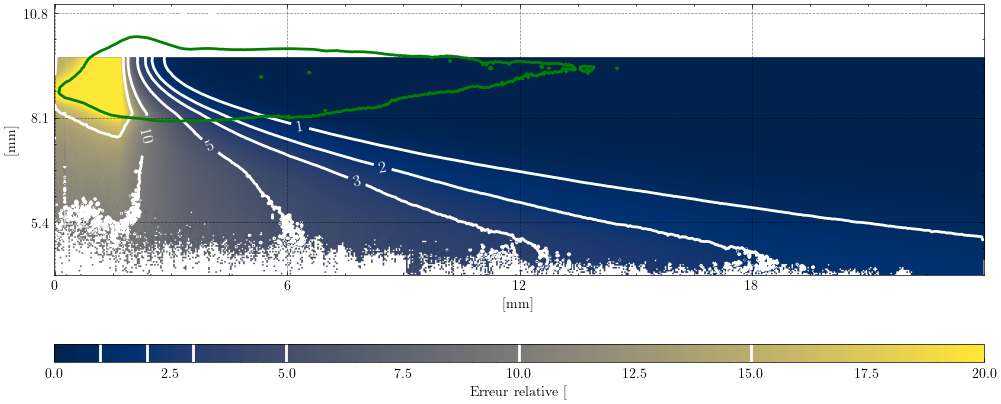

In [ ]:
absolute_error = np.abs(
    thermal_image_uniform_emissivity_field - thermal_image_heterogenous_emissivity_field
    )
relative_error = 100*np.abs(thermal_image_uniform_emissivity_field - thermal_image_heterogenous_emissivity_field)/thermal_image_uniform_emissivity_field


fig, ax = plt.subplots(figsize=(12, 6))

# Tracé des contours
contours_1 = measure.find_contours(thermal_image_uniform_emissivity_field, T_SOLIDUS)
custom_levels = [1, 2, 3, 5, 10, 15]
IMAGE = np.ma.masked_array(relative_error, mask_prof)

# Contour and extent setup.
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)
X, Y = np.meshgrid(np.arange(COLUMNS_CRED), np.arange(LINES_CRED))

iso_emi = ax.contour(X, Y, relative_error, levels=custom_levels, colors='white', linewidths=2)
ax.clabel(iso_emi, inline=True, fontsize=12, fmt='%.0f')

# Tracé des contours symétriques
for contour in contours_1:
    symmetrical_contour = np.array(contour)
    symmetrical_contour[:, 0] = contour[:, 0]  # Symétrie sur l'axe Y
    ax.plot(symmetrical_contour[:, 1], symmetrical_contour[:, 0], color='green', linewidth=2)

# Affichage de l'image
image = ax.imshow(IMAGE, vmin=0, vmax=20, cmap='cividis')
ax.set_xlabel('[mm]')
ax.set_ylabel('[mm]')

# Définition des ticks factices
ax.set_xticks(np.arange(0, COLUMNS_CRED, 160))
ax.set_yticks(np.arange(LINES_CRED, 0, -72))
ax.set_xticklabels([f"{x:.0f}" for x in np.arange(0, COLUMNS_CRED, 160)*FAC])
ax.set_yticklabels([f"{y:.1f}" for y in np.arange(0, LINES_CRED, 72)*FAC])

lim = 218
ax.set_ylim(lim+186, lim)
cbar = fig.colorbar(image, orientation='horizontal', shrink=1, aspect=50, pad=0.15)
cbar.set_label('Erreur relative [%]')

for level in custom_levels:
    cbar.ax.axvline(level, color='white', linewidth=2, linestyle='-')

# plt.savefig("../resultats/erreur_relative_first_order.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()